In [5]:
%matplotlib inline

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Set FONT SIZE of x-axis and y-axis, legend, etc.
X_TICKS = [16, 32, 64, 128, 256, 512]
FONT_SIZE = 14
rc = {
    "axes.labelsize": FONT_SIZE,
    "font.size": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "legend.title_fontsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
}

sns.set_theme(style="whitegrid", palette="colorblind", context="notebook", rc=rc)
# pd.set_option("display.max_rows", None)

In [7]:
parquet_app_file = Path("./app_results.parquet")
df_app = pd.read_parquet(parquet_app_file)
df_app.loc[:, "nodes"] = df_app["nodes"].astype(float)
df_app.loc[:, "variation rate"] = df_app["variation rate"].astype(float)

parquet_sim_file = Path("./sim_results.parquet")
df_sim = pd.read_parquet(parquet_sim_file)
df_sim.loc[:, "value"] = df_sim["value"].astype(float).round(2)


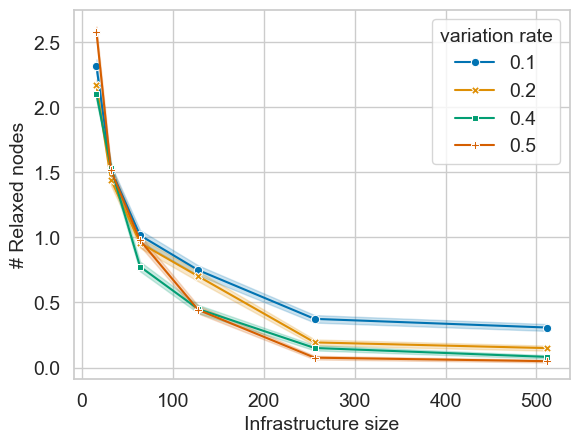

In [8]:
df_sc = df_app[(df_app["callback_id"] == "soft_constraints") & (df_app["relaxed"] == True)]
df_sc.loc[:, "value"] = df_sc["value"].astype(float)
df_sc = df_sc[(df_sc["value"] != -1)]

f_sc = sns.lineplot(
    data=df_sc,
    x="nodes",
    y="value",
    hue="variation rate",
    style="variation rate",
    markers=True,
    dashes=False,
    palette="colorblind",
)

plt.xlabel("Infrastructure size")
plt.ylabel("# Relaxed nodes")

plt.savefig(PLOTS_DIR / "relaxed_nodes.pdf", format="pdf", dpi=600)
plt.show()

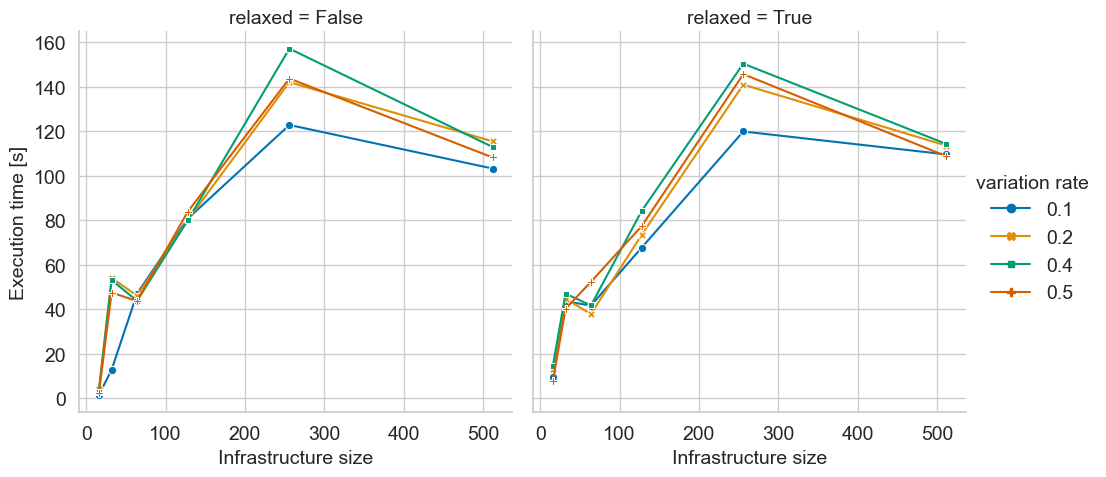

In [9]:
df_et = df_app[(df_app["callback_id"] == "execution_time")]
df_et.loc[:, "value"] = df_et["value"].astype(float).round(4)
df_et = df_et[~df_et["value"].isin([-1])]

f_et = sns.relplot(
    data=df_et,
    x="nodes",
    y="value",
    col="relaxed",
    hue="variation rate",
    style="variation rate",
    kind="line",
    markers=True,
    dashes=False,
    errorbar=None,
    palette="colorblind",
)

f_et.set_xlabels("Infrastructure size")
f_et.set_ylabels("Execution time [s]")
plt.savefig(PLOTS_DIR / "execution_times.pdf", format="pdf", dpi=600)
plt.show()

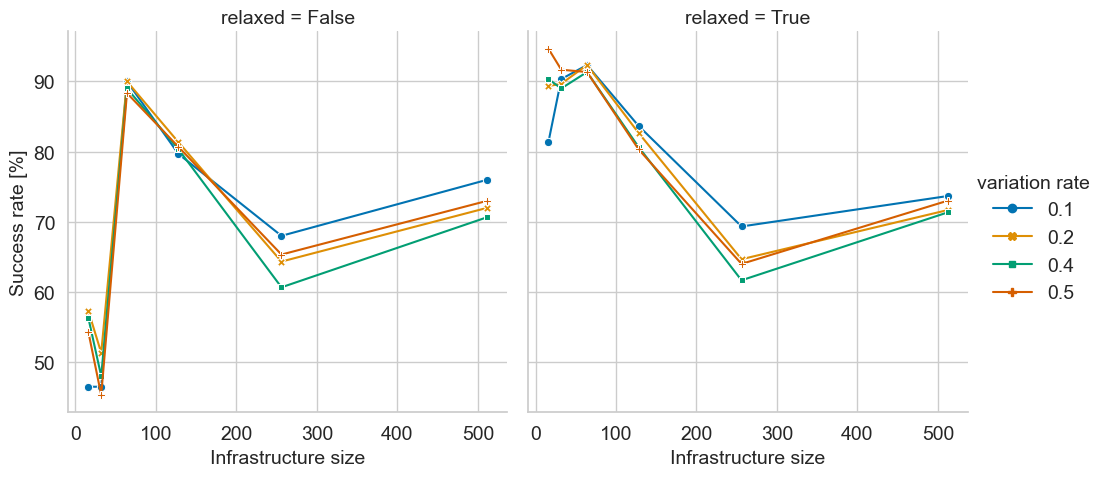

In [10]:
f_sr = sns.relplot(
    data=df_sim,
    x="nodes",
    y=df_sim["value"]*100,
    col="relaxed",
    hue="variation rate",
    style="variation rate",
    kind="line",
    markers=True,
    dashes=False,
    errorbar=None,
    palette="colorblind",
)

f_sr.set_xlabels("Infrastructure size")
f_sr.set_ylabels("Success rate [%]")
plt.savefig(PLOTS_DIR / "success-rate.pdf", format="pdf", dpi=600)
plt.show()